<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Cuaderno_de_An%C3%A1lisis_Validaci%C3%B3n_Predicci%C3%B3n_LSTM_con_ACF_Decomp_Autoajuste_Gr%C3%A1ficos_ok_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías importadas correctamente.
Datos cargados exitosamente con 14 tipos de incidentes.

¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': validar

INICIANDO MODO VALIDACIÓN (BACKTESTING con Autoajuste LSTM)
----------------------------------------------------------------------
VALIDANDO Y AJUSTANDO MODELO LSTM PARA: 'Abigeato'


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando búsqueda de hiperparámetros...
Mejores hiperparámetros: Unidades=128, Dropout=0.20, LR=0.0001


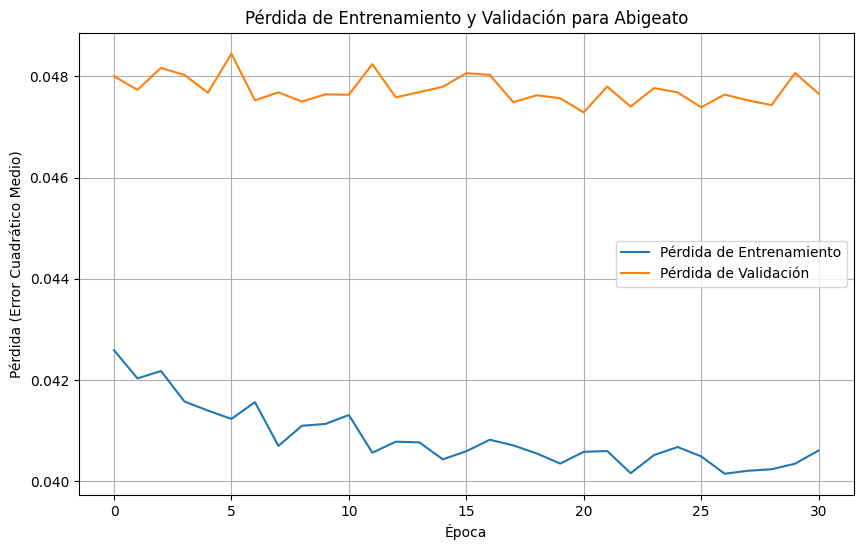

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step
RESULTADOS DE VALIDACIÓN: RMSE=0.22 | R²=-0.00


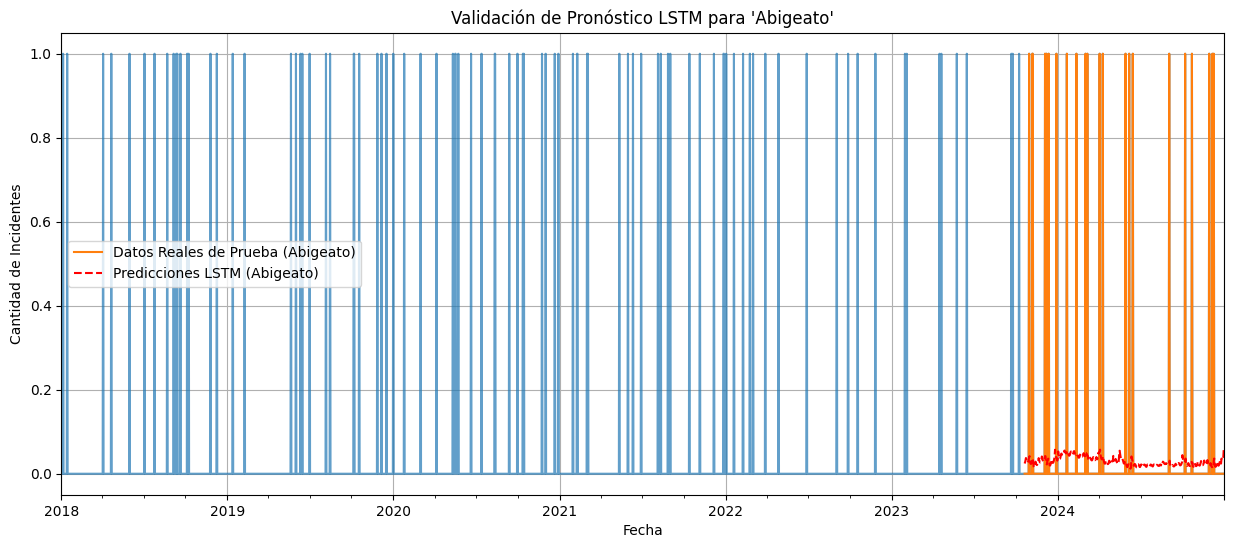

----------------------------------------------------------------------
VALIDANDO Y AJUSTANDO MODELO LSTM PARA: 'Coaccion sexual'
Iniciando búsqueda de hiperparámetros...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [2]:
# -*- coding: utf-8 -*-
"""
Cuaderno de Análisis y Predicción (LSTM con Autoajuste y Gráficos)
Versión 13.2 - Deep Learning Optimizado con Visualizaciones Completas

Objetivo: Incorporar gráficos de validación y de pronóstico futuro en el
          flujo de trabajo del modelo LSTM con autoajuste.

Librerías Adicionales Requiridas:
pip install tensorflow keras-tuner
"""
#pip install tensorflow keras-tuner
# -----------------------------------------------------------------------------
# Paso 1: Importación de Librerías
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import holidays
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
print("Librerías importadas correctamente.")

# -----------------------------------------------------------------------------
# --- CONFIGURACIÓN DE PARÁMETROS ---
# -----------------------------------------------------------------------------
N_STEPS = 365
LAGS_TO_PLOT = 40

# -----------------------------------------------------------------------------
# Paso 2: Funciones Comunes
# -----------------------------------------------------------------------------

def crear_caracteristicas(dataframe):
    df_copy = dataframe.copy()
    df_copy['dia_de_la_semana'] = df_copy.index.dayofweek
    df_copy['mes'] = df_copy.index.month
    df_copy['anio'] = df_copy.index.year
    df_copy['dia_del_anio'] = df_copy.index.dayofyear
    df_copy['semana_del_anio'] = df_copy.index.isocalendar().week.astype(int)
    py_holidays = holidays.Paraguay(years=df_copy.index.year.unique())
    df_copy['es_feriado'] = df_copy.index.isin(py_holidays).astype(int)
    return df_copy

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix > len(data)-1:
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, 0]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# -----------------------------------------------------------------------------
# --- MODO ANÁLISIS ---
# -----------------------------------------------------------------------------

def analizar_series_temporales(dataframe, lags):
    print("\n" + "="*70)
    print("INICIANDO MODO ANÁLISIS (ACF/PACF/Descomposición Estacional)")
    print("="*70)
    for incidente in dataframe.columns:
        if dataframe[incidente].sum() < 20: continue
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        plot_acf(dataframe[incidente], ax=ax1, lags=lags)
        ax1.set_title(f'ACF para {incidente}')
        plot_pacf(dataframe[incidente], ax=ax2, lags=lags)
        ax2.set_title(f'PACF para {incidente}')
        plt.tight_layout()
        plt.show()

        # Añadir gráfico de descomposición estacional
        try:
            decomposition = seasonal_decompose(dataframe[incidente], model='additive', period=365)
            fig = decomposition.plot()
            fig.set_size_inches(15, 8) # Increase the figure size for better x-axis readability
            fig.suptitle(f'Descomposición Estacional para {incidente}', y=1.02) # Añade título a la figura completa

            # Traducir títulos de los ejes Y
            axes = fig.get_axes()
            if len(axes) >= 4:
                axes[0].set_ylabel('Observado')
                axes[1].set_ylabel('Tendencia')
                axes[2].set_ylabel('Estacionalidad')
                axes[3].set_ylabel('Residuales')

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"No se pudo realizar la descomposición estacional para {incidente}: {e}")


# -----------------------------------------------------------------------------
# --- MODO VALIDACIÓN (LSTM con Autoajuste) ---
# -----------------------------------------------------------------------------

def build_model(hp):
    """Función constructora de modelos para Keras Tuner."""
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
    model.add(Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error'
    )
    return model

X_train = None # Variable global necesaria para que build_model conozca el input_shape

def validar_modelo_lstm(dataframe, target_column):
    global X_train
    print("-" * 70)
    print(f"VALIDANDO Y AJUSTANDO MODELO LSTM PARA: '{target_column}'")

    df_with_features = crear_caracteristicas(dataframe[[target_column]].copy())
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df_with_features)

    X, y = create_sequences(scaled_data, N_STEPS)

    if len(X) < 50:
        print("Datos insuficientes.")
        return None

    split_point = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:split_point], X[split_point:], y[:split_point], y[split_point:]

    tuner = kt.RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=5,
        executions_per_trial=1,
        directory='keras_tuner_dir_lstm',
        project_name=f'tuner_lstm_{target_column}',
        overwrite=True
    )

    print("Iniciando búsqueda de hiperparámetros...")
    tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
                 callbacks=[EarlyStopping(monitor='val_loss', patience=5)], verbose=0)

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Mejores hiperparámetros: Unidades={best_hps.get('units')}, Dropout={best_hps.get('dropout'):.2f}, LR={best_hps.get('learning_rate')}")

    best_model = tuner.hypermodel.build(best_hps)
    # Entrenar el mejor modelo y guardar el historial
    history = best_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test),
                   callbacks=[EarlyStopping(monitor='val_loss', patience=10)], verbose=0)

    # Graficar la pérdida de entrenamiento y validación
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de Validación')
    plt.title(f'Pérdida de Entrenamiento y Validación para {target_column}')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Error Cuadrático Medio)')
    plt.legend()
    plt.grid(True)
    plt.show()


    y_pred_scaled = best_model.predict(X_test)

    y_pred_padded = np.zeros((len(y_pred_scaled), scaled_data.shape[1]))
    y_pred_padded[:, 0] = y_pred_scaled.ravel()
    y_pred = scaler.inverse_transform(y_pred_padded)[:, 0]

    y_test_padded = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_padded[:, 0] = y_test.ravel()
    y_test_inv = scaler.inverse_transform(y_test_padded)[:, 0]

    rmse, r2 = np.sqrt(mean_squared_error(y_test_inv, y_pred)), r2_score(y_test_inv, y_pred)
    print(f"RESULTADOS DE VALIDACIÓN: RMSE={rmse:.2f} | R²={r2:.2f}")

    # --- Gráfico de Validación ---
    fechas_test = df_with_features.index[split_point + N_STEPS:]
    df_resultados = pd.DataFrame(index=fechas_test, data={'Reales': y_test_inv, 'Predicciones': y_pred})

    fig, ax = plt.subplots(figsize=(15, 6))
    df_with_features[target_column].plot(ax=ax, label='Histórico Completo', alpha=0.7)
    df_resultados['Reales'].plot(ax=ax, label=f'Datos Reales de Prueba ({target_column})', legend=True)
    df_resultados['Predicciones'].plot(ax=ax, label=f'Predicciones LSTM ({target_column})', legend=True, color='red', linestyle='--')
    ax.set_title(f"Validación de Pronóstico LSTM para '{target_column}'")
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad de Incidentes')
    ax.grid(True)
    plt.show()

    return best_hps

# -----------------------------------------------------------------------------
# --- MODO PRODUCCIÓN (LSTM) ---
# -----------------------------------------------------------------------------

def producir_con_lstm(dataframe, target_column, hps, model_path, scaler_path, horizonte):
    print(f"\n--- Entrenando y prediciendo con LSTM para '{target_column}' ---")

    df_with_features = crear_caracteristicas(dataframe[[target_column]].copy())
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df_with_features)
    joblib.dump(scaler, scaler_path)

    X, y = create_sequences(scaled_data, N_STEPS)

    if len(X) < 50:
        print(f"Datos insuficientes.")
        return np.zeros(horizonte)

    global X_train
    X_train = X

    final_model = build_model(hps)
    final_model.fit(X, y, epochs=100, callbacks=[EarlyStopping(monitor='loss', patience=10)], verbose=0)
    final_model.save(model_path)
    print(f"Modelo de producción guardado en: {model_path}")

    last_sequence = scaled_data[-N_STEPS:]
    predictions_scaled = []

    for _ in range(horizonte):
        input_seq = last_sequence.reshape((1, N_STEPS, scaled_data.shape[1]))
        pred = final_model.predict(input_seq, verbose=0)
        predictions_scaled.append(pred[0][0])

        new_row_features_dummy = np.zeros((1, scaled_data.shape[1]-1))
        new_row = np.concatenate([pred, new_row_features_dummy], axis=1)
        last_sequence = np.append(last_sequence[1:], new_row, axis=0)

    y_pred_padded = np.zeros((len(predictions_scaled), scaled_data.shape[1]))
    y_pred_padded[:, 0] = np.array(predictions_scaled).ravel()
    predictions_inv = scaler.inverse_transform(y_pred_padded)[:, 0]

    return np.round(np.maximum(0, predictions_inv)).astype(int)

# =============================================================================
# --- PUNTO DE ENTRADA PRINCIPAL ---
# =============================================================================

if __name__ == '__main__':
    try:
        df_incidents = pd.read_csv('incidentes_ampliados_7_anios_completo.csv', encoding='utf-8')
        df_incidents['fecha'] = pd.to_datetime(df_incidents['fecha'])
        df_pivot = pd.pivot_table(df_incidents, index='fecha', columns='tipo_incidente', aggfunc='size', fill_value=0)
        date_rng = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq='D')
        df_granular = df_pivot.reindex(date_rng, fill_value=0)
        print(f"Datos cargados exitosamente con {len(df_granular.columns)} tipos de incidentes.")
    except FileNotFoundError:
        print("\nERROR: El archivo 'incidentes_ampliados_7_anios_completo.csv' no se encontró.")
        exit()

    while True:
        modo = input("\n¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': ").lower().strip()
        if modo in ['analizar', 'validar', 'predecir']:
            break
        else:
            print("Entrada no válida. Por favor, intente de nuevo.")

    if modo == 'analizar':
        analizar_series_temporales(df_granular, lags=LAGS_TO_PLOT)

    elif modo == 'validar':
        print("\n" + "="*70)
        print("INICIANDO MODO VALIDACIÓN (BACKTESTING con Autoajuste LSTM)")
        print("="*70)
        for incidente in df_granular.columns:
            validar_modelo_lstm(df_granular, incidente)

    elif modo == 'predecir':
        print("\n" + "="*70)
        print("INICIANDO MODO PRODUCCIÓN (ENTRENAMIENTO Y PREDICCIÓN con LSTM)")
        print("="*70)

        mejores_hps = {}
        for incidente in df_granular.columns:
            hps = validar_modelo_lstm(df_granular, incidente)
            if hps:
                mejores_hps[incidente] = hps

        while True:
            try:
                dias_str = input("\n¿Cuántos días hacia el futuro desea predecir? (1-90): ")
                dias_a_predecir = int(dias_str)
                if 1 <= dias_a_predecir <= 90: break
                else: print("Error: Por favor, ingrese un número entre 1 y 90.")
            except ValueError:
                print("Error: Entrada no válida.")

        model_dir = "modelos_guardados_lstm_tuned"
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)

        last_known_date = df_granular.index.max()
        future_dates = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=dias_a_predecir, freq='D')
        df_pronostico_total = pd.DataFrame(index=future_dates)

        for incidente, hps in mejores_hps.items():
            if hps:
                model_path = os.path.join(model_dir, f"modelo_{incidente.lower().replace(' ', '_')}.h5")
                scaler_path = os.path.join(model_dir, f"scaler_{incidente.lower().replace(' ', '_')}.joblib")
                predicciones = producir_con_lstm(df_granular, incidente, hps, model_path, scaler_path, dias_a_predecir)
                df_pronostico_total[incidente] = predicciones

        df_pronostico_final = df_pronostico_total.fillna(0).astype(int)

        print("\n" + "-"*70)
        print(f"RESULTADO FINAL: TABLA DE PRONÓSTICO")
        print("-" * 70)
        print(df_pronostico_total)

        output_filename = 'pronostico_futuro_lstm_tuned.csv'
        df_pronostico_final.to_csv(output_filename, encoding='utf-8')
        print(f"\n¡Éxito! El pronóstico ha sido guardado en: '{output_filename}'")

        # --- Gráficos de Pronóstico Futuro ---
        print("\n" + "="*70)
        print("GENERANDO GRÁFICOS DE PRONÓSTICO FUTURO")
        print("="*70)
        for incidente in df_pronostico_final.columns:
            if incidente in df_granular.columns:
                fig, ax = plt.subplots(figsize=(15, 6))
                historial_reciente = df_granular.loc[df_granular.index > last_known_date - pd.DateOffset(months=3)][[incidente]]
                historial_reciente.plot(ax=ax, label=f'Histórico Real ({incidente})', legend=True)
                df_pronostico_final[[incidente]].plot(ax=ax, label=f'Pronóstico Futuro ({incidente})', legend=True, color='red', linestyle='--')
                ax.set_title(f"Pronóstico Futuro LSTM vs. Histórico Reciente para '{incidente}'")
                ax.set_xlabel('Fecha')
                ax.set_ylabel('Cantidad de Incidentes')
                ax.grid(True)
                plt.show()